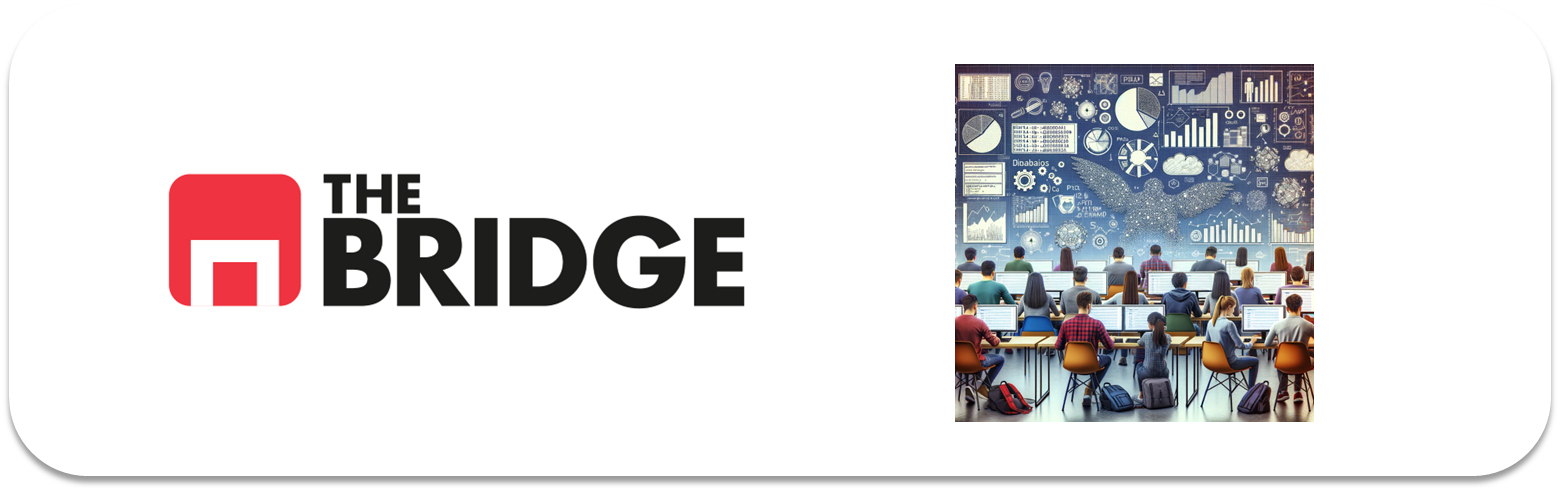

## PRACTICA OBLIGATORIA: **Clasificacion y Regresion Logistica**

* La práctica obligatoria de esta unidad consiste en modelar la supervivencia en el Titanic, por fin, además de una parte adicional multiclase. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión logística, evaluarlo contra un dataset de test reservado del original mostrando las métricas propias de los problemas de clasificación, la matriz de confusión y la curva ROC. Además se pide comparar las predicciones con los valores reales y al final adaptar el modelo a un problema multiclase.

Los pasos para guiar el trabajo:
1. Carga el dataset del Titanic. 
2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.
3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.
4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.
5. Construye las parejas X,y de train y test.
6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.
7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
8. Trata las variables para que funcionen lo mejor posible en el modelo.
9. Construye un modelo de regresión logística.
10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.
11. Procesa el dataset de Test para que puedas usarlo en la evaluación 
12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.
13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.
14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.  



1. Carga el dataset del Titanic. 

In [2]:
df = pd.read_csv("./data/titanic.csv")
print(f"Shape: {df.shape}")

Shape: (891, 15)


In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [7]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.

In [8]:
cols_to_drop = ["alive", "class", "who", "adult_male", "embark_town", "alone", "deck"]
df = df.drop(columns=cols_to_drop)

3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.

In [9]:
target = "survived"

In [10]:
print("Distribucion absoluta del target:")
print(df["survived"].value_counts())
print()
print("Proporcion:")
print(df["survived"].value_counts(normalize=True).round(3))

Distribucion absoluta del target:
survived
0    549
1    342
Name: count, dtype: int64

Proporcion:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


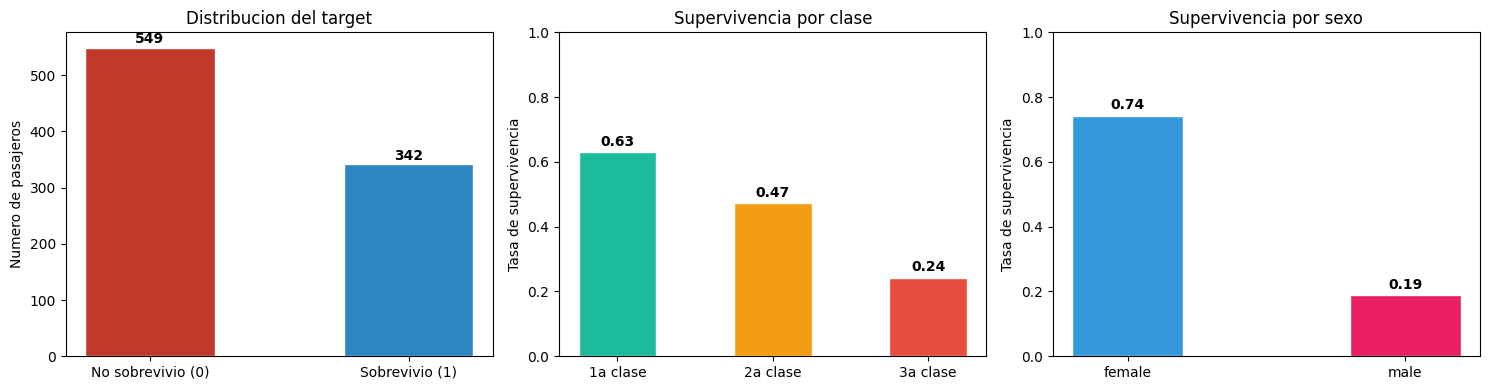

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribucion absoluta del target
counts = df["survived"].value_counts()
axes[0].bar(
    ["No sobrevivio (0)", "Sobrevivio (1)"],
    counts.values,
    color=["#C0392B", "#2E86C1"],
    edgecolor="white", width=0.5
)
axes[0].set_title("Distribucion del target")
axes[0].set_ylabel("Numero de pasajeros")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 8, str(v), ha="center", fontweight="bold")

# Tasa de supervivencia por clase
surv_class = df.groupby("pclass")["survived"].mean()
axes[1].bar(
    ["1a clase", "2a clase", "3a clase"],
    surv_class.values,
    color=["#1ABC9C", "#F39C12", "#E74C3C"],
    edgecolor="white", width=0.5
)
axes[1].set_title("Supervivencia por clase")
axes[1].set_ylabel("Tasa de supervivencia")
axes[1].set_ylim(0, 1)
for i, v in enumerate(surv_class.values):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")

# Tasa de supervivencia por sexo
surv_sex = df.groupby("sex")["survived"].mean()
axes[2].bar(
    surv_sex.index, surv_sex.values,
    color=["#3498DB", "#E91E63"],
    edgecolor="white", width=0.4
)
axes[2].set_title("Supervivencia por sexo")
axes[2].set_ylabel("Tasa de supervivencia")
axes[2].set_ylim(0, 1)
for i, v in enumerate(surv_sex.values):
    axes[2].text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

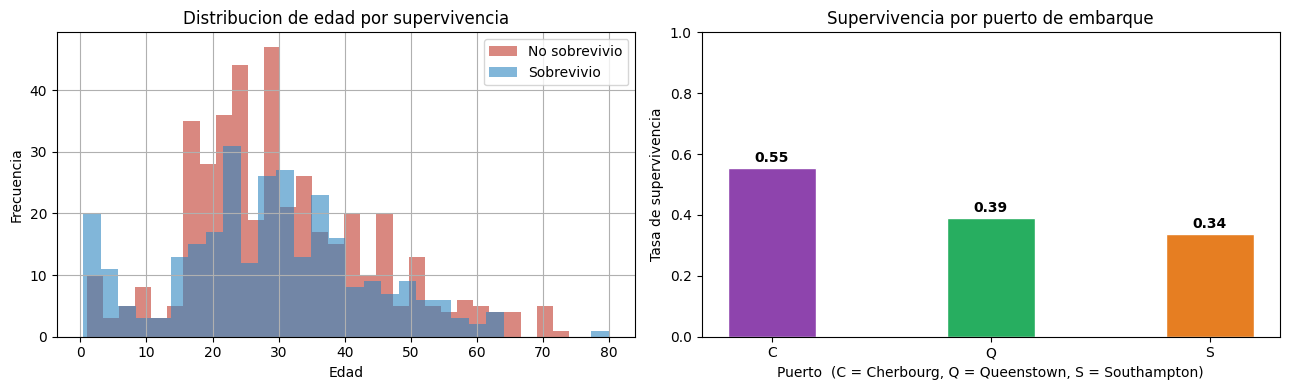

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribucion de edad por supervivencia
df[df["survived"] == 0]["age"].dropna().hist(
    ax=axes[0], bins=30, alpha=0.6, color="#C0392B", label="No sobrevivio"
)
df[df["survived"] == 1]["age"].dropna().hist(
    ax=axes[0], bins=30, alpha=0.6, color="#2E86C1", label="Sobrevivio"
)
axes[0].set_title("Distribucion de edad por supervivencia")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Tasa de supervivencia por puerto de embarque
surv_emb = df.groupby("embarked")["survived"].mean().dropna()
axes[1].bar(
    surv_emb.index, surv_emb.values,
    color=["#8E44AD", "#27AE60", "#E67E22"],
    edgecolor="white", width=0.4
)
axes[1].set_title("Supervivencia por puerto de embarque")
axes[1].set_xlabel("Puerto  (C = Cherbourg, Q = Queenstown, S = Southampton)")
axes[1].set_ylabel("Tasa de supervivencia")
axes[1].set_ylim(0, 1)
for i, v in enumerate(surv_emb.values):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.

In [13]:
df_valid   = df.dropna(subset=["embarked"]).copy()
df_nullemb = df[df["embarked"].isna()].copy()

print(f"Registros con embarked valido:          {len(df_valid)}")
print(f"Registros con embarked nulo (a train):  {len(df_nullemb)}")

train_df, test_df = train_test_split(
    df_valid,
    test_size=0.20,
    stratify=df_valid["embarked"],
    random_state=42
)

train_df = pd.concat([train_df, df_nullemb], ignore_index=True)

print(f"\nTrain: {train_df.shape}  |  Test: {test_df.shape}")
print("\nDistribucion de embarked en train:")
print(train_df["embarked"].value_counts(normalize=True).round(3))
print("\nDistribucion de embarked en test:")
print(test_df["embarked"].value_counts(normalize=True).round(3))

Registros con embarked valido:          889
Registros con embarked nulo (a train):  2

Train: (713, 8)  |  Test: (178, 8)

Distribucion de embarked en train:
embarked
S    0.724
C    0.188
Q    0.087
Name: proportion, dtype: float64

Distribucion de embarked en test:
embarked
S    0.725
C    0.191
Q    0.084
Name: proportion, dtype: float64


5. Construye las parejas X,y de train y test.


In [14]:
TARGET = "survived"

X_train_raw = train_df.drop(columns=[TARGET]).copy()
y_train     = train_df[TARGET].copy()

X_test_raw  = test_df.drop(columns=[TARGET]).copy()
y_test      = test_df[TARGET].copy()

print(f"X_train: {X_train_raw.shape}  |  y_train: {y_train.shape}")
print(f"X_test:  {X_test_raw.shape}   |  y_test:  {y_test.shape}")
print(f"\nProporcion survived en train: {y_train.mean():.3f}")
print(f"Proporcion survived en test:  {y_test.mean():.3f}")

X_train: (713, 7)  |  y_train: (713,)
X_test:  (178, 7)   |  y_test:  (178,)

Proporcion survived en train: 0.383
Proporcion survived en test:  0.388


6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.

In [15]:
# Calcular estadisticos SOLO sobre X_train
age_mean_train = X_train_raw["age"].mean()
emb_mode_train = X_train_raw["embarked"].mode()[0]

print(f"Media de age en train:     {age_mean_train:.4f}")
print(f"Moda de embarked en train: {emb_mode_train}")

# Aplicar imputacion sobre X_train
X_train = X_train_raw.copy()
X_train["age"]      = X_train["age"].fillna(age_mean_train)
X_train["embarked"] = X_train["embarked"].fillna(emb_mode_train)

print(f"\nNulos en X_train tras imputacion:")
print(X_train.isnull().sum())

Media de age en train:     29.7810
Moda de embarked en train: S

Nulos en X_train tras imputacion:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.


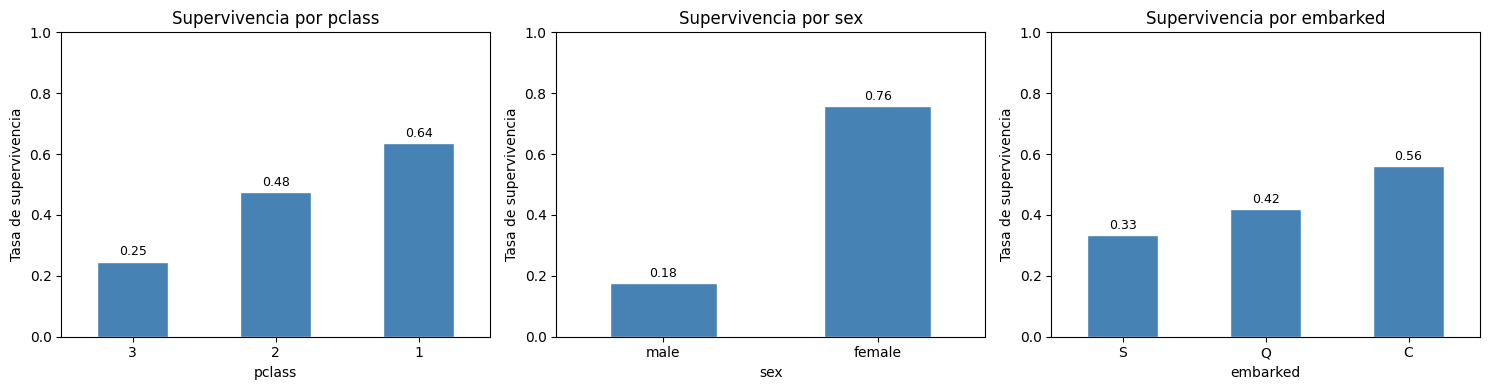

In [16]:
# Tasa de supervivencia por variables categoricas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
train_plot = X_train.assign(survived=y_train)

for ax, col in zip(axes, ["pclass", "sex", "embarked"]):
    tasa = train_plot.groupby(col)["survived"].mean().sort_values()
    tasa.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Supervivencia por {col}")
    ax.set_ylabel("Tasa de supervivencia")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=0)
    for i, v in enumerate(tasa.values):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

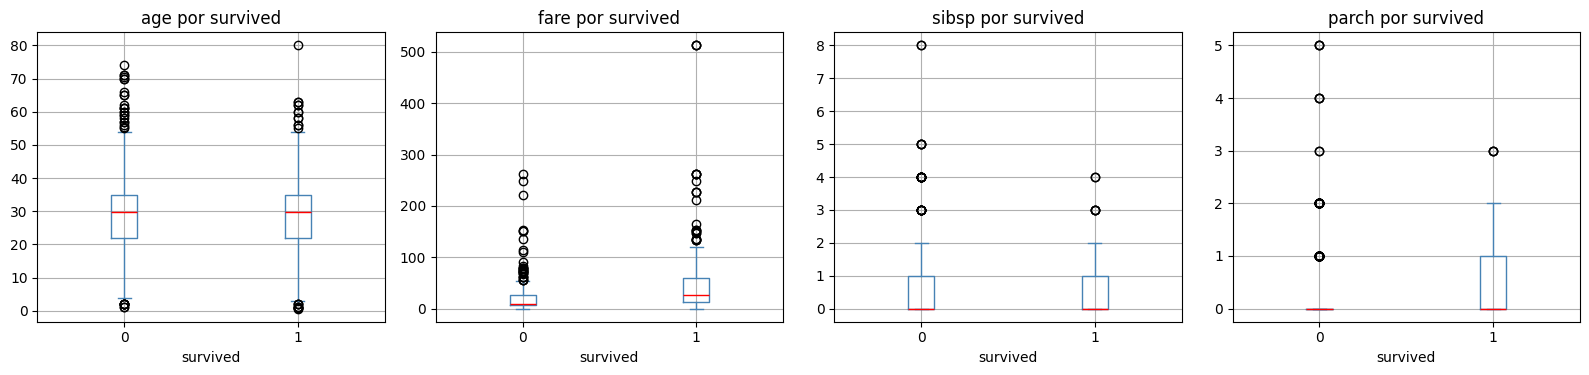

In [17]:
# Boxplots de variables numericas por supervivencia
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, ["age", "fare", "sibsp", "parch"]):
    train_plot.boxplot(
        column=col, by="survived", ax=ax,
        boxprops=dict(color="steelblue"),
        medianprops=dict(color="red"),
        whiskerprops=dict(color="steelblue"),
        capprops=dict(color="steelblue")
    )
    ax.set_title(f"{col} por survived")
    ax.set_xlabel("survived")

plt.suptitle("")
plt.tight_layout()
plt.show()

Correlacion de Pearson con survived:
pclass   -0.338
age      -0.042
sibsp    -0.009
parch     0.090
fare      0.271
Name: survived, dtype: float64


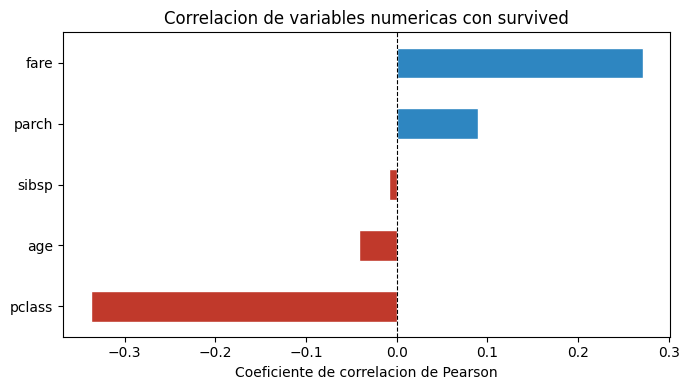

In [18]:
# Correlacion de variables numericas con survived
corr_num = train_plot[["pclass", "age", "sibsp", "parch", "fare", "survived"]].corr()
corr_target = corr_num["survived"].drop("survived").sort_values()

print("Correlacion de Pearson con survived:")
print(corr_target.round(3))

plt.figure(figsize=(7, 4))
colors = ["#C0392B" if v < 0 else "#2E86C1" for v in corr_target]
corr_target.plot(kind="barh", color=colors, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Correlacion de variables numericas con survived")
plt.xlabel("Coeficiente de correlacion de Pearson")
plt.tight_layout()
plt.show()

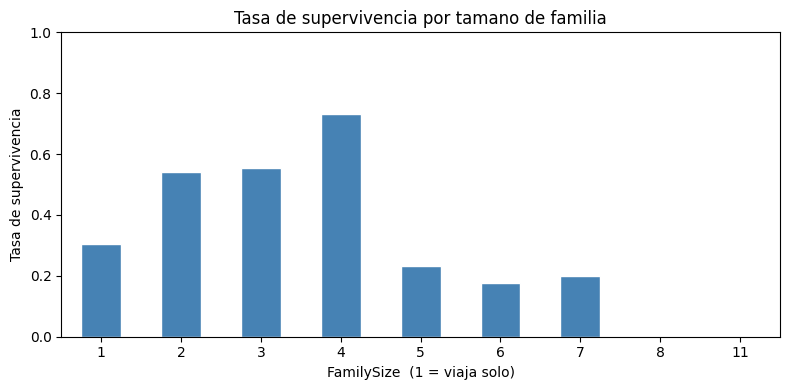

Distribucion de FamilySize:
FamilySize
1     432
2     124
3      85
4      26
5      13
6      17
7      10
8       4
11      2
Name: count, dtype: int64


In [19]:
X_train["FamilySize"] = X_train["sibsp"] + X_train["parch"] + 1

# Visualizacion: supervivencia por tamano de familia
fs_surv = X_train.assign(survived=y_train).groupby("FamilySize")["survived"].mean()

plt.figure(figsize=(8, 4))
fs_surv.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Tasa de supervivencia por tamano de familia")
plt.xlabel("FamilySize  (1 = viaja solo)")
plt.ylabel("Tasa de supervivencia")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Distribucion de FamilySize:")
print(X_train["FamilySize"].value_counts().sort_index())

8. Trata las variables para que funcionen lo mejor posible en el modelo.


In [20]:
# One-Hot Encoding
X_train_enc = pd.get_dummies(X_train, columns=["sex", "embarked"], drop_first=True)

# Convertir booleanos a entero
bool_cols = X_train_enc.select_dtypes(include="bool").columns
X_train_enc[bool_cols] = X_train_enc[bool_cols].astype(int)

# Eliminar sibsp y parch (sustituidas por FamilySize)
X_train_enc = X_train_enc.drop(columns=["sibsp", "parch"])

print("Columnas tras encoding:")
print(X_train_enc.columns.tolist())
print(f"Shape: {X_train_enc.shape}")

Columnas tras encoding:
['pclass', 'age', 'fare', 'FamilySize', 'sex_male', 'embarked_Q', 'embarked_S']
Shape: (713, 7)


In [21]:
# Escalado — scaler ajustado SOLO sobre train
cols_to_scale = ["pclass", "age", "fare", "FamilySize"]

scaler = StandardScaler()
X_train_enc[cols_to_scale] = scaler.fit_transform(X_train_enc[cols_to_scale])

# Guardar orden de columnas para replicarlo exactamente en test
FEATURE_COLS = X_train_enc.columns.tolist()

print("X_train preprocesada — primeras filas:")
X_train_enc.head()

X_train preprocesada — primeras filas:


,pclass,age,fare,FamilySize,sex_male,embarked_Q,embarked_S
0,0.800879,2.717024e-16,-0.318211,0.091228,1,1,0
1,-1.613609,3.991336e-01,1.010237,0.091228,0,0,1
2,0.800879,1.697014e-01,-0.318211,0.768790,0,1,0
3,0.800879,2.717024e-16,-0.162843,1.446351,0,0,1
4,-1.613609,2.461788e-01,0.416613,0.091228,0,0,1


9. Construye un modelo de regresión logística.


In [22]:
model = LogisticRegression(
    class_weight="balanced",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

model.fit(X_train_enc, y_train)

print("Modelo entrenado correctamente.")
print(f"Iteraciones realizadas: {model.n_iter_[0]}")
print(f"Intercepto:             {model.intercept_[0]:.4f}")

Modelo entrenado correctamente.
Iteraciones realizadas: 14
Intercepto:             1.8174


10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.


In [23]:
coef_df = pd.DataFrame({
    "Feature":     FEATURE_COLS,
    "Coeficiente": model.coef_[0]
}).sort_values("Coeficiente", ascending=True).reset_index(drop=True)

print("Coeficientes del modelo (log-odds, variables escaladas):")
print(coef_df.to_string(index=False))

Coeficientes del modelo (log-odds, variables escaladas):
   Feature  Coeficiente
  sex_male    -2.636543
    pclass    -0.716919
       age    -0.391021
FamilySize    -0.373520
embarked_S    -0.363890
embarked_Q    -0.010316
      fare     0.221949


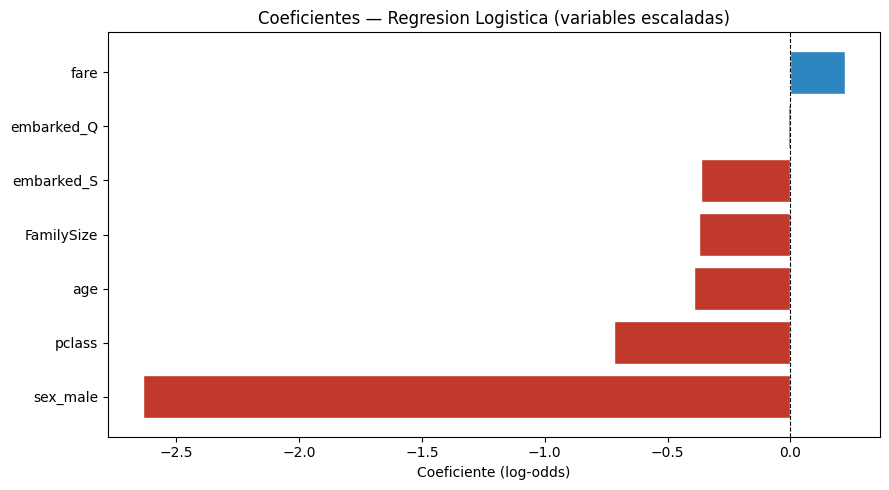

In [24]:
colors = ["#C0392B" if c < 0 else "#2E86C1" for c in coef_df["Coeficiente"]]

plt.figure(figsize=(9, 5))
plt.barh(coef_df["Feature"], coef_df["Coeficiente"], color=colors, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Coeficientes — Regresion Logistica (variables escaladas)")
plt.xlabel("Coeficiente (log-odds)")
plt.tight_layout()
plt.show()

11. Procesa el dataset de Test para que puedas usarlo en la evaluación 


In [25]:
X_test = X_test_raw.copy()

# Imputacion con estadisticos de TRAIN
X_test["age"]      = X_test["age"].fillna(age_mean_train)
X_test["embarked"] = X_test["embarked"].fillna(emb_mode_train)

# Feature engineering identico
X_test["FamilySize"] = X_test["sibsp"] + X_test["parch"] + 1
X_test = X_test.drop(columns=["sibsp", "parch"])

# Encoding
X_test_enc = pd.get_dummies(X_test, columns=["sex", "embarked"], drop_first=True)
bool_cols_t = X_test_enc.select_dtypes(include="bool").columns
X_test_enc[bool_cols_t] = X_test_enc[bool_cols_t].astype(int)

# Alinear columnas con train
X_test_enc = X_test_enc.reindex(columns=FEATURE_COLS, fill_value=0)

# Escalado con parametros de TRAIN
X_test_enc[cols_to_scale] = scaler.transform(X_test_enc[cols_to_scale])

print(f"X_test procesada: {X_test_enc.shape}")
print(f"Nulos en X_test:  {X_test_enc.isnull().sum().sum()}")
print(f"Columnas: {X_test_enc.columns.tolist()}")

X_test procesada: (178, 7)
Nulos en X_test:  0
Columnas: ['pclass', 'age', 'fare', 'FamilySize', 'sex_male', 'embarked_Q', 'embarked_S']


12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.


In [26]:
y_pred_train  = model.predict(X_train_enc)
y_pred_test   = model.predict(X_test_enc)

y_proba_train = model.predict_proba(X_train_enc)[:, 1]
y_proba_test  = model.predict_proba(X_test_enc)[:, 1]

In [27]:
print("=" * 58)
print("  CLASSIFICATION REPORT — TRAIN")
print("=" * 58)
print(classification_report(
    y_train, y_pred_train,
    target_names=["No sobrevivio (0)", "Sobrevivio (1)"]
))

print("=" * 58)
print("  CLASSIFICATION REPORT — TEST")
print("=" * 58)
print(classification_report(
    y_test, y_pred_test,
    target_names=["No sobrevivio (0)", "Sobrevivio (1)"]
))

  CLASSIFICATION REPORT — TRAIN
                   precision    recall  f1-score   support

No sobrevivio (0)       0.84      0.81      0.83       440
   Sobrevivio (1)       0.71      0.75      0.73       273

         accuracy                           0.79       713
        macro avg       0.78      0.78      0.78       713
     weighted avg       0.79      0.79      0.79       713

  CLASSIFICATION REPORT — TEST
                   precision    recall  f1-score   support

No sobrevivio (0)       0.83      0.78      0.81       109
   Sobrevivio (1)       0.68      0.75      0.72        69

         accuracy                           0.77       178
        macro avg       0.76      0.77      0.76       178
     weighted avg       0.78      0.77      0.77       178



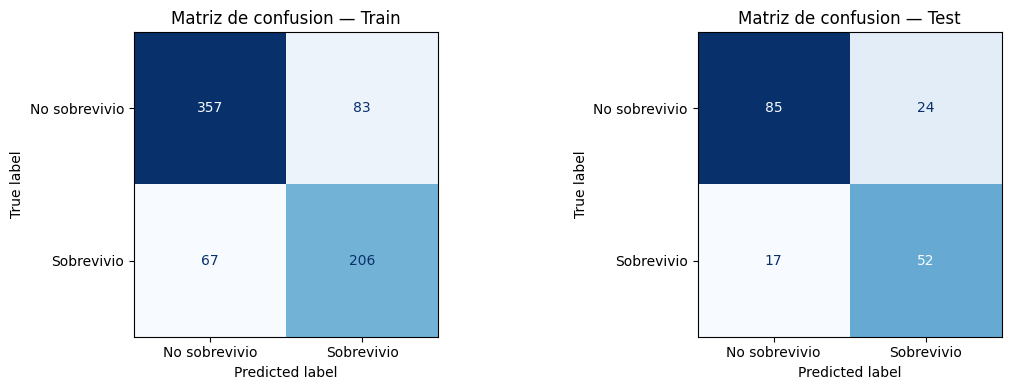

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_true, y_pred, titulo in zip(
    axes,
    [y_train, y_test],
    [y_pred_train, y_pred_test],
    ["Matriz de confusion — Train", "Matriz de confusion — Test"]
):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        cm, display_labels=["No sobrevivio", "Sobrevivio"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(titulo)

plt.tight_layout()
plt.show()

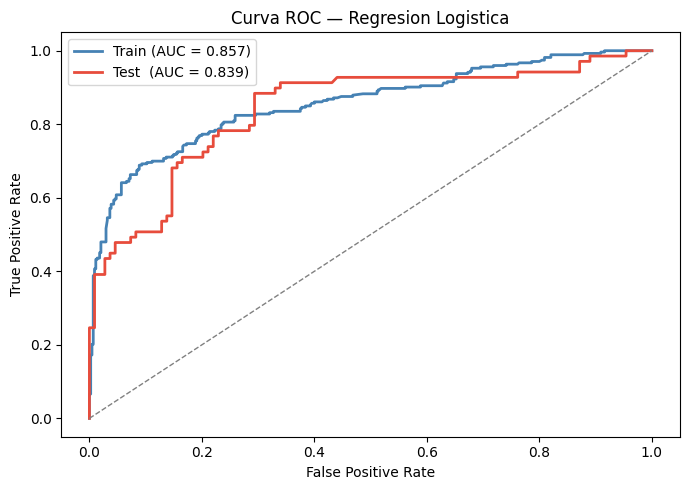

In [29]:
fpr_train, tpr_train, _ = roc_curve(y_train, y_proba_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_proba_test)

auc_train = roc_auc_score(y_train, y_proba_train)
auc_test  = roc_auc_score(y_test,  y_proba_test)

plt.figure(figsize=(7, 5))
plt.plot(fpr_train, tpr_train,
         label=f"Train (AUC = {auc_train:.3f})", color="steelblue", lw=2)
plt.plot(fpr_test,  tpr_test,
         label=f"Test  (AUC = {auc_test:.3f})",  color="#E74C3C",   lw=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — Regresion Logistica")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Comparacion directa: predicciones vs valores reales (primeras 20 de test)
comparison = pd.DataFrame({
    "Real":      y_test.values[:20],
    "Predicho":  y_pred_test[:20],
    "Prob_surv": y_proba_test[:20].round(3),
    "Correcto":  (y_test.values[:20] == y_pred_test[:20])
})

print("Primeras 20 predicciones vs valores reales (test):")
print(comparison.to_string(index=False))

n_ok = (y_test.values == y_pred_test).sum()
print(f"\nTotal correctas en test: {n_ok} / {len(y_test)}  ({n_ok/len(y_test)*100:.1f}%)")

Primeras 20 predicciones vs valores reales (test):
 Real  Predicho  Prob_surv  Correcto
    0         0      0.162      True
    1         1      0.714      True
    0         1      0.803     False
    1         1      0.853      True
    1         1      0.946      True
    1         1      0.842      True
    0         0      0.338      True
    0         0      0.196      True
    0         0      0.263      True
    0         0      0.219      True
    0         0      0.366      True
    0         0      0.162      True
    1         0      0.409     False
    1         1      0.919      True
    1         1      0.796      True
    1         1      0.818      True
    0         0      0.251      True
    0         0      0.308      True
    1         0      0.153     False
    1         0      0.373     False

Total correctas en test: 137 / 178  (77.0%)


13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.


14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report. 